<div style="background:linear-gradient(135deg,#001F3F 0%,#EE3A43 100%);padding:40px 32px;border-left:6px solid #0093D5;">
<h1 style="color:#fff;font-family:Arial,sans-serif;font-size:28px;margin:0 0 8px;">08b — 5G Root Cause Analysis · Dataset 2</h1>
<h2 style="color:rgba(255,255,255,.75);font-family:Arial,sans-serif;font-size:16px;font-weight:400;margin:0 0 20px;">SpiriCom · Subscriber KPI Classification · XGBoost + SHAP · 5G Cohort Deep-Dive</h2>
<div style="display:flex;gap:32px;flex-wrap:wrap;">
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Input</strong><br/>churn_features.parquet + churn_scores.parquet</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Target</strong><br/>risk_level (Critical / High / Medium / Low)</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">5G Filter</strong><br/>ratio_5g &gt; 10% → 5G cohort</div>
<div style="color:rgba(255,255,255,.65);font-size:13px;"><strong style="color:#fff;">Output</strong><br/>models/classification/rca_5g_results.json</div>
</div></div>

---
## What this notebook does

**Dataset isolation:** Dataset 1 (complaints) and Dataset 2 (subscriber KPIs) are analysed
completely separately. This notebook covers **Dataset 2 only**.

```
Question: For a 5G subscriber, which KPI feature is the TRUE root cause
          of their network problem?

Both files below are Dataset 2 — they share the same 4,896 MSISDNs:
  churn_features.parquet  → 24 KPI features per subscriber
  churn_scores.parquet    → risk_level per subscriber (from NB05)

Join: churn_features + churn_scores ON msisdn → adds risk_level to features

Target: risk_level (Critical / High / Medium / Low)
  → 4-class classification: which KPI combination puts a subscriber at risk?

5G Cohort: filter ratio_5g > 10% → analyse KPI drivers specifically
           for subscribers actively using 5G

SHAP answer: for 5G users at HIGH/CRITICAL risk,
             which KPI feature matters most?
             → That is the root cause of the 5G problem.
```

### Why risk_level as target (not complaint_typology)?

| | complaint_typology | risk_level |
|-|-------------------|------------|
| Source dataset | Dataset 1 | Dataset 2 |
| Available in D2? | ❌ No | ✅ Yes (from NB05) |
| Meaning | Type of complaint ticket | Churn + network risk score |
| 5G relevance | Indirect | Direct (KPI-driven) |
| Classes | Coverage/Speed/Voice/… | Critical/High/Medium/Low |

In [19]:
# ══════════════════════════════════════════════════════════════════════
# §0. IMPORTS & PATHS
# ══════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy  as np
import json, warnings, joblib
from pathlib  import Path

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import LabelEncoder
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import xgboost as xgb
import shap
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

DATA_DIR  = Path('data')
PROC_DIR  = Path('data/processed')
OUT_DIR   = Path('data/outputs')
MODEL_DIR = Path('models')
CLASS_DIR = MODEL_DIR / 'classification'
FIG_DIR   = OUT_DIR  / 'figures'
for d in [CLASS_DIR, FIG_DIR]: d.mkdir(parents=True, exist_ok=True)

HW = dict(blue='#0093D5', red='#EE3A43', navy='#001F3F', green='#22C55E',
          amber='#F59E0B', purple='#8B5CF6', muted='#6B7280', cyan='#22D3EE')
plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white','axes.edgecolor':'#E5E7EB',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,
    'axes.grid.axis':'y','grid.color':'#F3F4F6','axes.labelcolor':HW['navy'],
    'axes.labelweight':'bold','axes.titlesize':13,'axes.titleweight':'bold',
    'axes.titlecolor':HW['navy'],'xtick.color':HW['muted'],'ytick.color':HW['muted'],
    'figure.dpi':110,'savefig.dpi':300,'savefig.bbox':'tight',
})
def save_fig(name):
    p = FIG_DIR / f'{name}.png'
    plt.savefig(p, dpi=300, bbox_inches='tight', facecolor='white')
    print(f'  Saved: {p}')
def wm(fig):
    fig.text(.99,.01,'SpiriCom · Huawei Technologies Tunisia',
             ha='right',va='bottom',fontsize=7,color=HW['muted'],style='italic')
print('✅ Setup complete')

✅ Setup complete


---
## §1 — Load & Join Dataset 2 (churn_features + churn_scores)

In [20]:
# ── 1.1  Load churn_features.parquet ─────────────────────────────────
feat_df = None
for p in [
    OUT_DIR  / 'churn_features.parquet',
    PROC_DIR / 'churn_features.parquet',
]:
    if p.exists():
        feat_df = pd.read_parquet(p)
        feat_df.columns = feat_df.columns.str.lower().str.strip()
        print(f'churn_features: {len(feat_df):,} rows')
        print(f'All columns ({len(feat_df.columns)}):')
        for c in feat_df.columns:
            print(f'  {c:<35s} {str(feat_df[c].dtype):<12s} '
                  f'unique={feat_df[c].nunique():<6} nulls={feat_df[c].isna().sum()}')
        break

if feat_df is None:
    raise FileNotFoundError('churn_features.parquet not found — run NB04')

# ── 1.2  Load churn_scores.parquet ───────────────────────────────────
scores_df = None
for p in [
    OUT_DIR   / 'churn_scores.parquet',
    MODEL_DIR / 'churn_scores.parquet',
]:
    if p.exists():
        scores_df = pd.read_parquet(p)
        scores_df.columns = scores_df.columns.str.lower().str.strip()
        print(f'\nchurn_scores: {len(scores_df):,} rows')
        print(f'Columns: {list(scores_df.columns)}')
        if 'risk_level' in scores_df.columns:
            print(f'\nrisk_level distribution:')
            print(scores_df['risk_level'].value_counts().to_string())
        break

if scores_df is None:
    raise FileNotFoundError('churn_scores.parquet not found — run NB05')

churn_features: 4,896 rows
All columns (26):
  msisdn                              object       unique=4896   nulls=0
  churn                               int64        unique=2      nulls=0
  avg_packet_loss                     float64      unique=1102   nulls=0
  avg_latency_ms                      float64      unique=2821   nulls=0
  client_rtt_ms                       float64      unique=2778   nulls=0
  voip_quality                        float64      unique=1061   nulls=0
  session_active_rate                 int64        unique=2      nulls=0
  ratio_5g                            float64      unique=3050   nulls=0
  total_traffic                       float64      unique=3517   nulls=0
  traffic_5g                          float64      unique=379    nulls=0
  duration                            float64      unique=1522   nulls=0
  nightly_ratio                       float64      unique=3081   nulls=0
  gaming_ratio                        float64      unique=3474   nulls=0
  soci

In [21]:
# ── 1.3  Join on msisdn (both are Dataset 2 — valid join) ─────────────
print('Joining churn_features + churn_scores on msisdn...')

# Columns to bring from churn_scores
SCORE_KEEP = ['msisdn','risk_level']
prob_col   = next((c for c in ['churn_probability','churn_prob'] if c in scores_df.columns), None)
if prob_col:
    SCORE_KEEP.append(prob_col)

df = feat_df.merge(
    scores_df[SCORE_KEEP],
    on='msisdn', how='inner'
)
print(f'Merged: {len(df):,} rows  (expected: ~4,896)')

# Normalise risk_level case → Title Case
if 'risk_level' in df.columns:
    df['risk_level'] = df['risk_level'].str.title()  # CRITICAL→Critical etc.
    print(f'\nrisk_level (Title Case):')
    print(df['risk_level'].value_counts().to_string())

# ── 1.4  5G cohort definition ─────────────────────────────────────────
RATIO_THRESHOLD = 0.10   # ratio_5g > 10% = active 5G user
ratio_col = 'ratio_5g' if 'ratio_5g' in df.columns else None

if ratio_col:
    mask_5g  = df[ratio_col] > RATIO_THRESHOLD
    df_5g    = df[mask_5g].copy()
    df_non5g = df[~mask_5g].copy()
    print(f'\n5G cohort  (ratio_5g > {RATIO_THRESHOLD}): {len(df_5g):,}  '
          f'({len(df_5g)/len(df)*100:.1f}%)')
    print(f'Non-5G:                            {len(df_non5g):,}  '
          f'({len(df_non5g)/len(df)*100:.1f}%)')
else:
    df_5g = df.copy()
    print('⚠ ratio_5g column not found — treating all subscribers as 5G cohort')

Joining churn_features + churn_scores on msisdn...
Merged: 4,896 rows  (expected: ~4,896)

risk_level (Title Case):
risk_level
Medium      1979
Low         1435
Critical     971
High         511

5G cohort  (ratio_5g > 0.1): 1,157  (23.6%)
Non-5G:                            3,739  (76.4%)


KPI feature columns (24):
  avg_packet_loss                     mean=   0.0002  std=   0.0017
  avg_latency_ms                      mean= 255.2363  std= 561.9480
  client_rtt_ms                       mean= 191.3710  std= 415.9758
  voip_quality                        mean=   0.0946  std=   0.1153
  session_active_rate                 mean=   0.0498  std=   0.2176
  ratio_5g                            mean=   0.1708  std=   0.3367
  total_traffic                       mean=529122922.1818  std=899254682.1020
  traffic_5g                          mean=18390459.8562  std=150629736.6137
  duration                            mean= 715.7686  std=1245.8991
  nightly_ratio                       mean=   0.2529  std=   0.2575
  gaming_ratio                        mean=   0.0264  std=   0.1318
  social_ratio                        mean=   0.7912  std=   0.2025
  traffic_diversity                   mean=   1.8576  std=   0.3751
  brand_encoded                       mean=  54.4524  std=  24.2799
  b

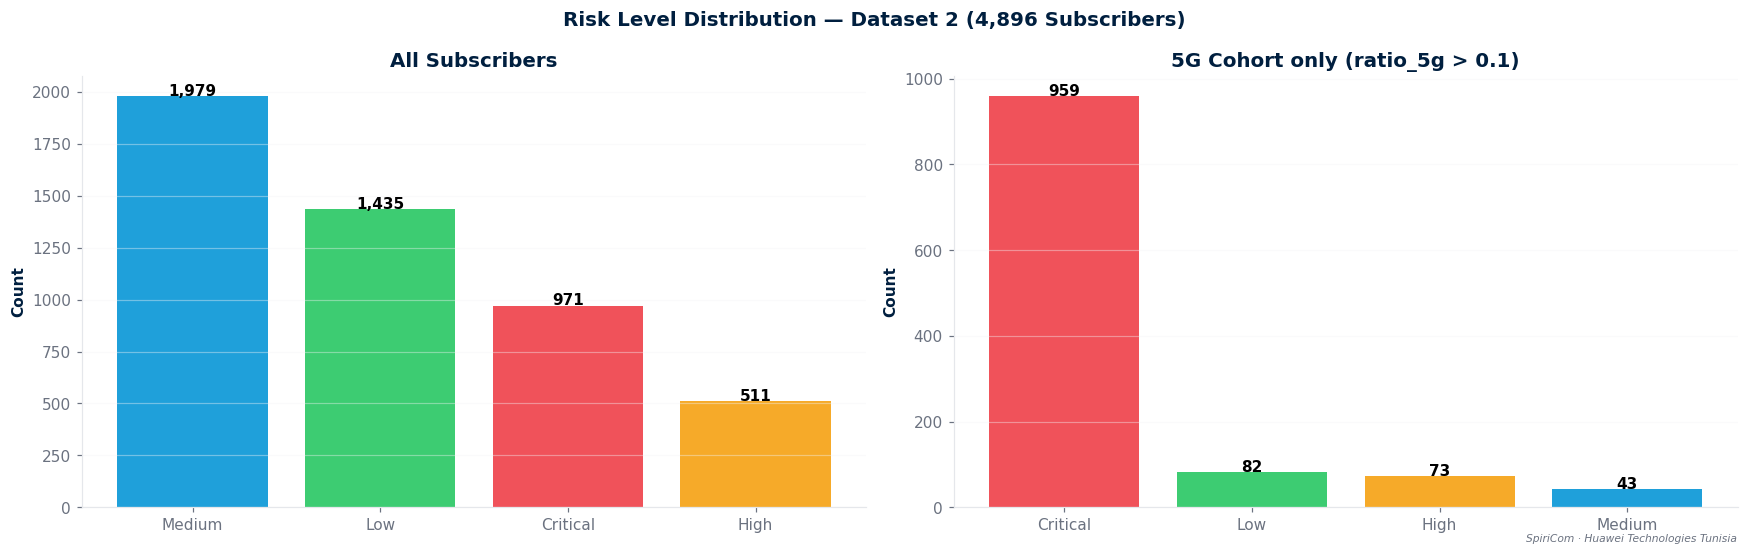

In [22]:
# ── 2.1  Define KPI feature set ───────────────────────────────────────
# These are the actual KPI columns confirmed from user's data
TARGET_COL = 'risk_level'

LEAKAGE = {
    'msisdn', 'churn', 'churn_predicted', 'churn_actual',
    'risk_level', 'churn_probability', 'churn_prob', 'churn_prob_xgb',
    'c1_low_usage', 'c2_low_dur',   # binary flags from clustering
}

FEATURE_COLS = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in LEAKAGE
]

print(f'KPI feature columns ({len(FEATURE_COLS)}):')
for c in FEATURE_COLS:
    mu  = df[c].mean()
    std = df[c].std()
    print(f'  {c:<35s} mean={mu:9.4f}  std={std:9.4f}')

if len(FEATURE_COLS) == 0:
    raise ValueError('No numeric feature columns found. Check churn_features schema.')

# ── 2.2  Encode target ─────────────────────────────────────────────────
le_risk = LabelEncoder()
# Use only rows where risk_level is not null
df_model = df.dropna(subset=[TARGET_COL]).copy()
df_model['_y'] = le_risk.fit_transform(df_model[TARGET_COL].astype(str))

X   = df_model[FEATURE_COLS].fillna(df_model[FEATURE_COLS].median())
y   = df_model['_y'].values

print(f'\nTarget classes: {list(le_risk.classes_)}')
print(f'Class counts:   {dict(zip(le_risk.classes_, np.bincount(y)))}')

# ── 2.3  Visualise risk_level distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Risk Level Distribution — Dataset 2 (4,896 Subscribers)',
             fontsize=13, fontweight='bold', color=HW['navy'])

ax = axes[0]
risk_dist = df_model[TARGET_COL].value_counts()
risk_pal  = {'Critical':HW['red'],'High':HW['amber'],'Medium':HW['blue'],'Low':HW['green']}
colors    = [risk_pal.get(c, HW['muted']) for c in risk_dist.index]
bars = ax.bar(risk_dist.index, risk_dist.values, color=colors, alpha=0.88)
for bar, val in zip(bars, risk_dist.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('All Subscribers')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.4); ax.grid(axis='x', visible=False)

ax = axes[1]
if ratio_col and len(df_5g) > 0:
    risk_5g   = df_5g[TARGET_COL].value_counts()
    colors_5g = [risk_pal.get(c, HW['muted']) for c in risk_5g.index]
    bars = ax.bar(risk_5g.index, risk_5g.values, color=colors_5g, alpha=0.88)
    for bar, val in zip(bars, risk_5g.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(f'5G Cohort only (ratio_5g > {RATIO_THRESHOLD})')
else:
    ax.text(0.5, 0.5, 'ratio_5g not available', ha='center', va='center',
            transform=ax.transAxes, color=HW['muted'])
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.4); ax.grid(axis='x', visible=False)

wm(fig); plt.tight_layout()
save_fig('fig08b_A_risk_distribution')
plt.show()

---
## §2 — XGBoost Risk Level Classifier

Train: 3,916  |  Test: 980
Class weights: {'Critical': np.float64(1.26), 'High': np.float64(2.39), 'Low': np.float64(0.85), 'Medium': np.float64(0.62)}

Training XGBoost risk level classifier...
  Accuracy   : 0.9357
  F1 Macro   : 0.9226
  F1 Weighted: 0.9364
  CV F1 Macro: 0.9080 ± 0.0055
  Saved: data\outputs\figures\fig08b_B_risk_classifier.png


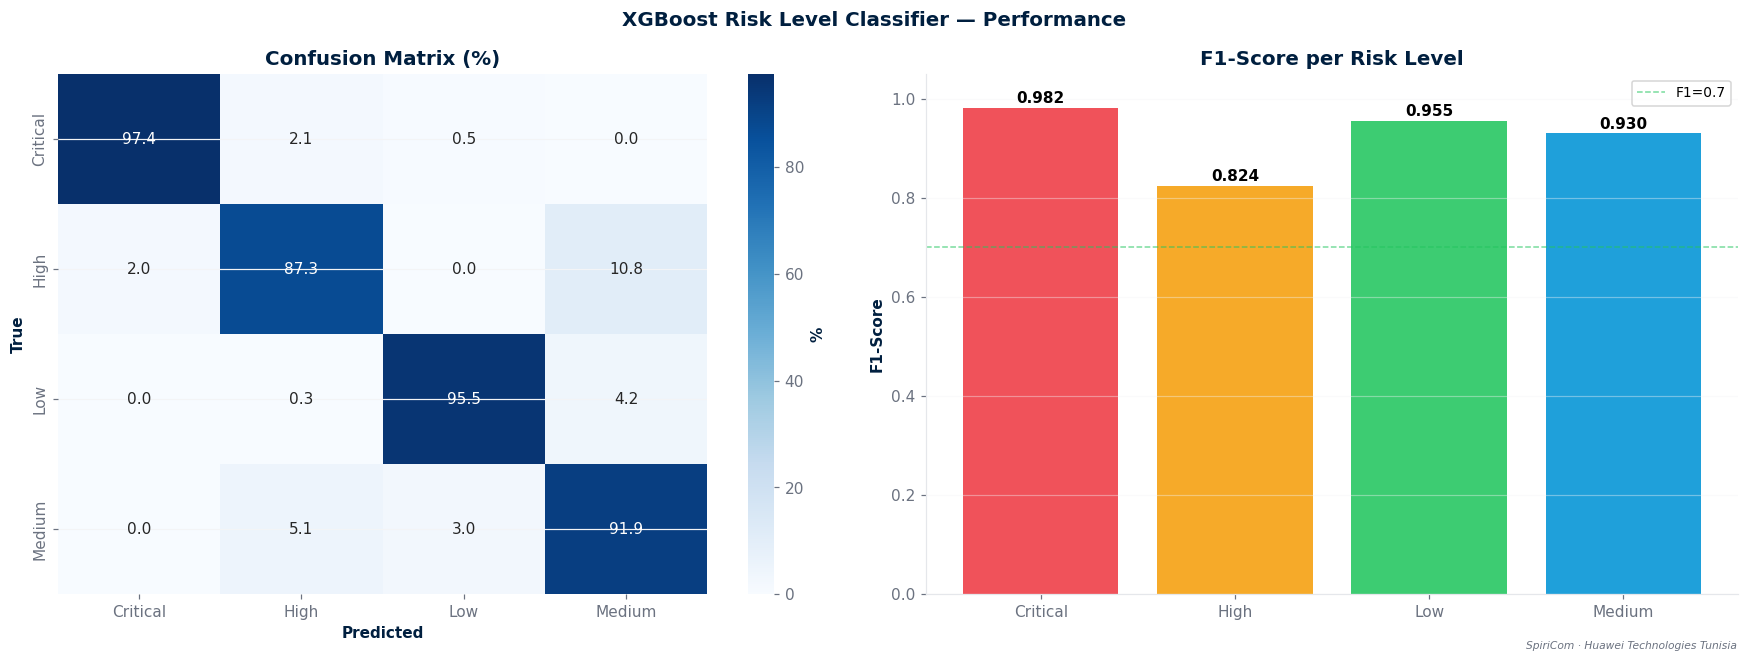

In [23]:
# ── 2.1  Train/test split ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

cw  = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sw  = np.array([dict(zip(np.unique(y_train), cw))[yi] for yi in y_train])
n_cls = len(le_risk.classes_)

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Class weights: {dict(zip(le_risk.classes_, cw.round(2)))}')

# ── 2.2  XGBoost ─────────────────────────────────────────────────────
print('\nTraining XGBoost risk level classifier...')
xgb_risk = xgb.XGBClassifier(
    n_estimators=400, max_depth=6, learning_rate=0.08,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    eval_metric='mlogloss', verbosity=0, n_jobs=-1,
    objective='multi:softprob' if n_cls > 2 else 'binary:logistic',
    num_class=n_cls if n_cls > 2 else None,
)
xgb_risk.fit(X_train, y_train, sample_weight=sw,
             eval_set=[(X_test, y_test)], verbose=False)

y_pred   = xgb_risk.predict(X_test)
acc      = accuracy_score(y_test, y_pred)
f1_mac   = f1_score(y_test, y_pred, average='macro',    zero_division=0)
f1_w     = f1_score(y_test, y_pred, average='weighted', zero_division=0)
cr       = classification_report(y_test, y_pred, target_names=le_risk.classes_,
                                  output_dict=True, zero_division=0)

print(f'  Accuracy   : {acc:.4f}')
print(f'  F1 Macro   : {f1_mac:.4f}')
print(f'  F1 Weighted: {f1_w:.4f}')

cv_scores = cross_val_score(
    xgb.XGBClassifier(n_estimators=100, max_depth=6, eval_metric='mlogloss',
                      random_state=42, n_jobs=-1, verbosity=0,
                      objective='multi:softprob' if n_cls>2 else 'binary:logistic',
                      num_class=n_cls if n_cls>2 else None),
    X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)
print(f'  CV F1 Macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost Risk Level Classifier — Performance',
             fontsize=13, fontweight='bold', color=HW['navy'])

ax = axes[0]
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=le_risk.classes_, yticklabels=le_risk.classes_,
            ax=ax, cbar_kws={'label':'%'})
ax.set_title('Confusion Matrix (%)')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')

ax = axes[1]
f1s    = [cr.get(c, {}).get('f1-score', 0) for c in le_risk.classes_]
bar_c  = [risk_pal.get(c, HW['muted']) for c in le_risk.classes_]
bars   = ax.bar(le_risk.classes_, f1s, color=bar_c, alpha=0.88)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0.7, color=HW['green'], lw=1, ls='--', alpha=0.6, label='F1=0.7')
ax.set_ylim(0, 1.05)
ax.set_title('F1-Score per Risk Level')
ax.set_ylabel('F1-Score'); ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.4); ax.grid(axis='x', visible=False)

wm(fig); plt.tight_layout()
save_fig('fig08b_B_risk_classifier')
plt.show()

---
## §3 — SHAP: Which KPI Drives Each Risk Level?

In [24]:
# ── SHAP shape helper ─────────────────────────────────────────────────
# XGBoost / SHAP version differences produce different output shapes:
#   list of (n_samples, n_features)          → older API, multi-class
#   ndarray (n_samples, n_features, n_classes) → newer API (axis order varies)
#   ndarray (n_classes, n_samples, n_features) → some versions
#   ndarray (n_samples, n_features)            → binary
# This function always returns shape (n_features,).

def shap_to_1d(sv, n_features):
    """
    Reduce SHAP values of any shape to a 1-D mean-|SHAP| array
    of length n_features.
    """
    arr = np.array(sv)

    if arr.ndim == 3:
        # Two possible axis orderings:
        #   (n_classes, n_samples, n_features)  → axis 2 has size n_features
        #   (n_samples, n_features, n_classes)  → axis 1 has size n_features
        if arr.shape[2] == n_features:       # (n_classes, n_samples, n_features)
            return np.abs(arr).mean(axis=(0, 1))
        elif arr.shape[1] == n_features:     # (n_samples, n_features, n_classes)
            return np.abs(arr).mean(axis=(0, 2))
        else:
            # Fallback: flatten everything and hope for the best
            return np.abs(arr).reshape(-1, n_features).mean(axis=0)

    elif arr.ndim == 2:
        if arr.shape[1] == n_features:       # (n_samples, n_features)
            return np.abs(arr).mean(axis=0)
        elif arr.shape[0] == n_features:     # (n_features, n_samples) — rare
            return np.abs(arr).mean(axis=1)

    # list of 2-D arrays
    elif isinstance(sv, list):
        return np.mean(
            [np.abs(np.array(s)).mean(axis=0) for s in sv], axis=0
        ).flatten()

    return np.abs(arr).flatten()[:n_features]


def shap_per_class(sv, n_features, n_classes):
    """
    Return list of n_classes arrays, each shape (n_features,),
    giving mean |SHAP| per class.
    """
    arr = np.array(sv)

    if arr.ndim == 3 and arr.shape[2] == n_features:  # (n_cls, n_samp, n_feat)
        return [np.abs(arr[i]).mean(axis=0) for i in range(n_classes)]

    elif arr.ndim == 3 and arr.shape[1] == n_features: # (n_samp, n_feat, n_cls)
        return [np.abs(arr[:, :, i]).mean(axis=0) for i in range(n_classes)]

    elif isinstance(sv, list) and len(sv) == n_classes:
        return [np.abs(np.array(sv[i])).mean(axis=0) for i in range(n_classes)]

    # Fallback: same global importance for every class
    global_imp = shap_to_1d(sv, n_features)
    return [global_imp] * n_classes


print('✅ shap_to_1d() and shap_per_class() defined')


✅ shap_to_1d() and shap_per_class() defined


In [25]:
# ── 3.1  Global SHAP — all subscribers ───────────────────────────────
print('Computing global SHAP (all subscribers)...')
X_shap_all = X_test.iloc[:min(500, len(X_test))]
explainer  = shap.TreeExplainer(xgb_risk)
sv_all     = explainer.shap_values(X_shap_all)

n_feat = len(FEATURE_COLS)
n_cls  = len(le_risk.classes_)

shap_global = shap_to_1d(sv_all, n_feat)
assert len(shap_global) == n_feat, \
    f'shap_to_1d returned {len(shap_global)}, expected {n_feat}'

shap_df_all = pd.DataFrame({'feature': FEATURE_COLS, 'shap_mean': shap_global})\
               .sort_values('shap_mean', ascending=False).reset_index(drop=True)

# ── 3.2  Per-class SHAP ───────────────────────────────────────────────
per_class_arrays = shap_per_class(sv_all, n_feat, n_cls)
per_class_shap   = {}
print(f'\nTop KPI driver per risk level:')
for i, cls in enumerate(le_risk.classes_):
    sv_cls = per_class_arrays[i]
    top    = sorted(zip(FEATURE_COLS, sv_cls), key=lambda x: x[1], reverse=True)[:5]
    per_class_shap[cls] = [{'feature': f, 'shap': round(float(v), 6)} for f, v in top]
    print(f'  {cls:<12s} → #1: {top[0][0]:<30s} ({top[0][1]:.4f})')
    print(f'             → #2: {top[1][0]:<30s} ({top[1][1]:.4f})')

print(f'\nTop 10 global SHAP drivers (all subscribers):')
for _, row in shap_df_all.head(10).iterrows():
    bar = chr(9608) * int(row.shap_mean / shap_df_all.shap_mean.max() * 25)
    print(f'  {row.feature:<35s}: {row.shap_mean:.5f}  {bar}')


Computing global SHAP (all subscribers)...

Top KPI driver per risk level:
  Critical     → #1: ratio_5g                       (4.2255)
             → #2: total_traffic                  (1.2952)
  High         → #1: duration                       (2.2068)
             → #2: traffic_diversity              (0.9313)
  Low          → #1: duration                       (3.2692)
             → #2: traffic_diversity              (0.9052)
  Medium       → #1: duration                       (1.0907)
             → #2: ratio_5g                       (0.6771)

Top 10 global SHAP drivers (all subscribers):
  duration                           : 1.83237  █████████████████████████
  ratio_5g                           : 1.54093  █████████████████████
  traffic_diversity                  : 0.69861  █████████
  total_traffic                      : 0.50484  ██████
  province_churn_rate                : 0.42672  █████
  generation_numeric                 : 0.38397  █████
  brand_churn_rate               

In [26]:
# ── 3.3  5G cohort SHAP — the core 5G RCA answer ─────────────────────
print('Computing SHAP for 5G cohort (ratio_5g > {}%)...'.format(int(RATIO_THRESHOLD*100)))

if ratio_col and len(df_5g) >= 10:
    X_5g        = df_5g[FEATURE_COLS].fillna(df_5g[FEATURE_COLS].median())
    X_5g_sample = X_5g.iloc[:min(500, len(X_5g))]

    sv_5g        = explainer.shap_values(X_5g_sample)
    shap_5g_mean = shap_to_1d(sv_5g, n_feat)

    shap_df_5g = pd.DataFrame({'feature': FEATURE_COLS, 'shap_5g': shap_5g_mean})\
                  .sort_values('shap_5g', ascending=False).reset_index(drop=True)

    # Critical + High only
    hi_mask  = df_5g['risk_level'].isin(['Critical','High']) \
               if 'risk_level' in df_5g.columns \
               else pd.Series(True, index=df_5g.index)
    df_5g_hi = df_5g[hi_mask]
    X_5g_hi  = df_5g_hi[FEATURE_COLS].fillna(df_5g_hi[FEATURE_COLS].median())

    if len(X_5g_hi) >= 5:
        sv_5g_hi      = explainer.shap_values(X_5g_hi.iloc[:min(300, len(X_5g_hi))])
        shap_5g_hi    = shap_to_1d(sv_5g_hi, n_feat)
        shap_df_5g_hi = pd.DataFrame({'feature': FEATURE_COLS, 'shap_hi': shap_5g_hi})\
                         .sort_values('shap_hi', ascending=False).reset_index(drop=True)
    else:
        shap_df_5g_hi = shap_df_5g.rename(columns={'shap_5g': 'shap_hi'})

    print(f'\n5G cohort       : {len(X_5g):,} subscribers')
    print(f'5G Critical+High: {len(df_5g_hi):,} subscribers')

    print(f'\nROOT CAUSE DRIVERS — 5G Critical+High subscribers:')
    print(f'{"Rank":<5} {"Feature":<35} {"SHAP":>8}  Bar')
    print('─' * 65)
    for rank, (_, row) in enumerate(shap_df_5g_hi.head(8).iterrows(), 1):
        bar = chr(9608) * int(row.shap_hi / shap_df_5g_hi.shap_hi.max() * 25)
        print(f'  #{rank:<3} {row.feature:<35s} {row.shap_hi:8.5f}  {bar}')
    print(f'\n  → Root cause #1: {shap_df_5g_hi.iloc[0]["feature"]}')
    print(f'  → Root cause #2: {shap_df_5g_hi.iloc[1]["feature"]}')
    print(f'  → Root cause #3: {shap_df_5g_hi.iloc[2]["feature"]}')

else:
    print('⚠ Not enough 5G subscribers — using global SHAP')
    shap_df_5g    = shap_df_all.rename(columns={'shap_mean': 'shap_5g'})
    shap_df_5g_hi = shap_df_all.rename(columns={'shap_mean': 'shap_hi'})


Computing SHAP for 5G cohort (ratio_5g > 10%)...

5G cohort       : 1,157 subscribers
5G Critical+High: 1,032 subscribers

ROOT CAUSE DRIVERS — 5G Critical+High subscribers:
Rank  Feature                                 SHAP  Bar
─────────────────────────────────────────────────────────────────
  #1   ratio_5g                             2.06353  █████████████████████████
  #2   duration                             1.11087  █████████████
  #3   total_traffic                        0.94210  ███████████
  #4   traffic_diversity                    0.68069  ████████
  #5   gaming_ratio                         0.32833  ███
  #6   province_churn_rate                  0.28905  ███
  #7   generation_numeric                   0.22563  ██
  #8   nightly_ratio                        0.19722  ██

  → Root cause #1: ratio_5g
  → Root cause #2: duration
  → Root cause #3: total_traffic


  Saved: data\outputs\figures\fig08b_C_5g_shap_decomposition.png


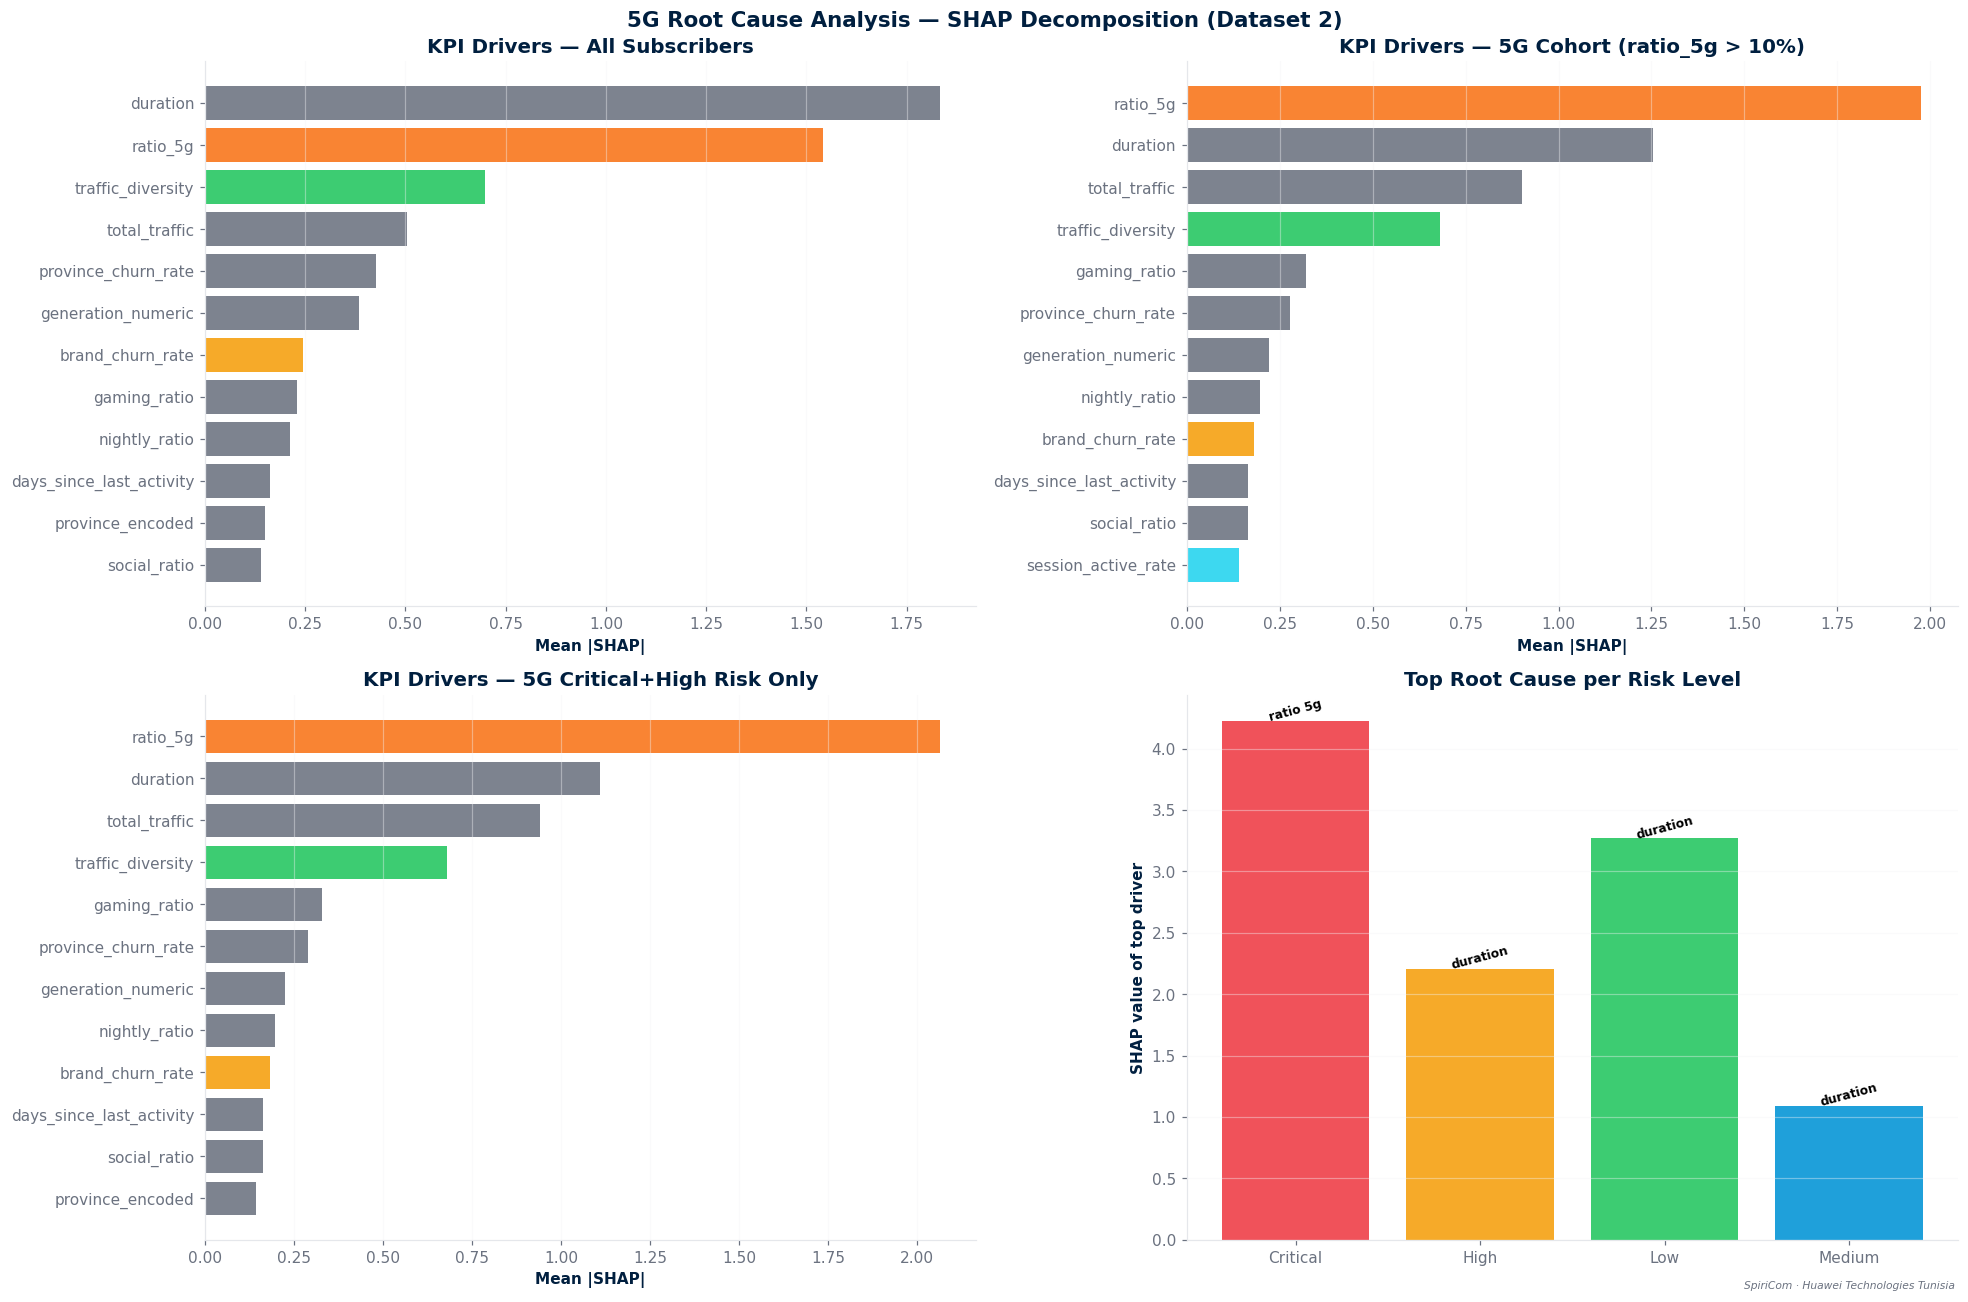

In [27]:
# ── 3.4  Visualise: 4-panel 5G RCA dashboard ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('5G Root Cause Analysis — SHAP Decomposition (Dataset 2)',
             fontsize=14, fontweight='bold', color=HW['navy'])

# Panel 1: Global SHAP all subscribers
ax = axes[0, 0]
top_all = shap_df_all.head(12)
col_map = {
    'avg_latency_ms':    HW['red'],
    'avg_packet_loss':   '#FF6B35',
    'client_rtt_ms':     HW['amber'],
    'voip_quality':      HW['purple'],
    'ratio_5g':          '#F97316',
    'traffic_5g':        HW['blue'],
    'session_active_rate': '#22D3EE',
    'congestion_level':  '#EC4899',
    'traffic_diversity': HW['green'],
    'brand_churn_rate':  '#F59E0B',
}
c_all = [col_map.get(f, HW['muted']) for f in top_all['feature']]
ax.barh(top_all['feature'][::-1], top_all['shap_mean'][::-1], color=c_all[::-1], alpha=0.88)
ax.set_title('KPI Drivers — All Subscribers')
ax.set_xlabel('Mean |SHAP|')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

# Panel 2: SHAP for 5G cohort
ax = axes[0, 1]
top_5g = shap_df_5g.head(12)
c_5g   = [col_map.get(f, HW['muted']) for f in top_5g['feature']]
ax.barh(top_5g['feature'][::-1], top_5g['shap_5g'][::-1], color=c_5g[::-1], alpha=0.88)
ax.set_title(f'KPI Drivers — 5G Cohort (ratio_5g > {int(RATIO_THRESHOLD*100)}%)')
ax.set_xlabel('Mean |SHAP|')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

# Panel 3: SHAP for Critical+High 5G
ax = axes[1, 0]
top_hi = shap_df_5g_hi.head(12)
c_hi   = [col_map.get(f, HW['muted']) for f in top_hi['feature']]
ax.barh(top_hi['feature'][::-1], top_hi['shap_hi'][::-1], color=c_hi[::-1], alpha=0.88)
ax.set_title('KPI Drivers — 5G Critical+High Risk Only')
ax.set_xlabel('Mean |SHAP|')
ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)

# Panel 4: Per risk class — top KPI driver
ax = axes[1, 1]
if per_class_shap:
    classes_plot = list(per_class_shap.keys())
    top_drivers  = [per_class_shap[c][0]['feature'] if per_class_shap[c] else 'N/A'
                    for c in classes_plot]
    top_vals     = [per_class_shap[c][0]['shap']    if per_class_shap[c] else 0
                    for c in classes_plot]
    risk_colors  = [risk_pal.get(c, HW['muted']) for c in classes_plot]
    bars = ax.bar(classes_plot, top_vals, color=risk_colors, alpha=0.88)
    for bar, driver, val in zip(bars, top_drivers, top_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                driver.replace('avg_','').replace('_',' '),
                ha='center', fontsize=8, fontweight='bold', rotation=15)
    ax.set_title('Top Root Cause per Risk Level')
    ax.set_ylabel('SHAP value of top driver')
    ax.grid(axis='y', alpha=0.4); ax.grid(axis='x', visible=False)

wm(fig); plt.tight_layout()
save_fig('fig08b_C_5g_shap_decomposition')
plt.show()

  Saved: data\outputs\figures\fig08b_D_kpi_profile.png


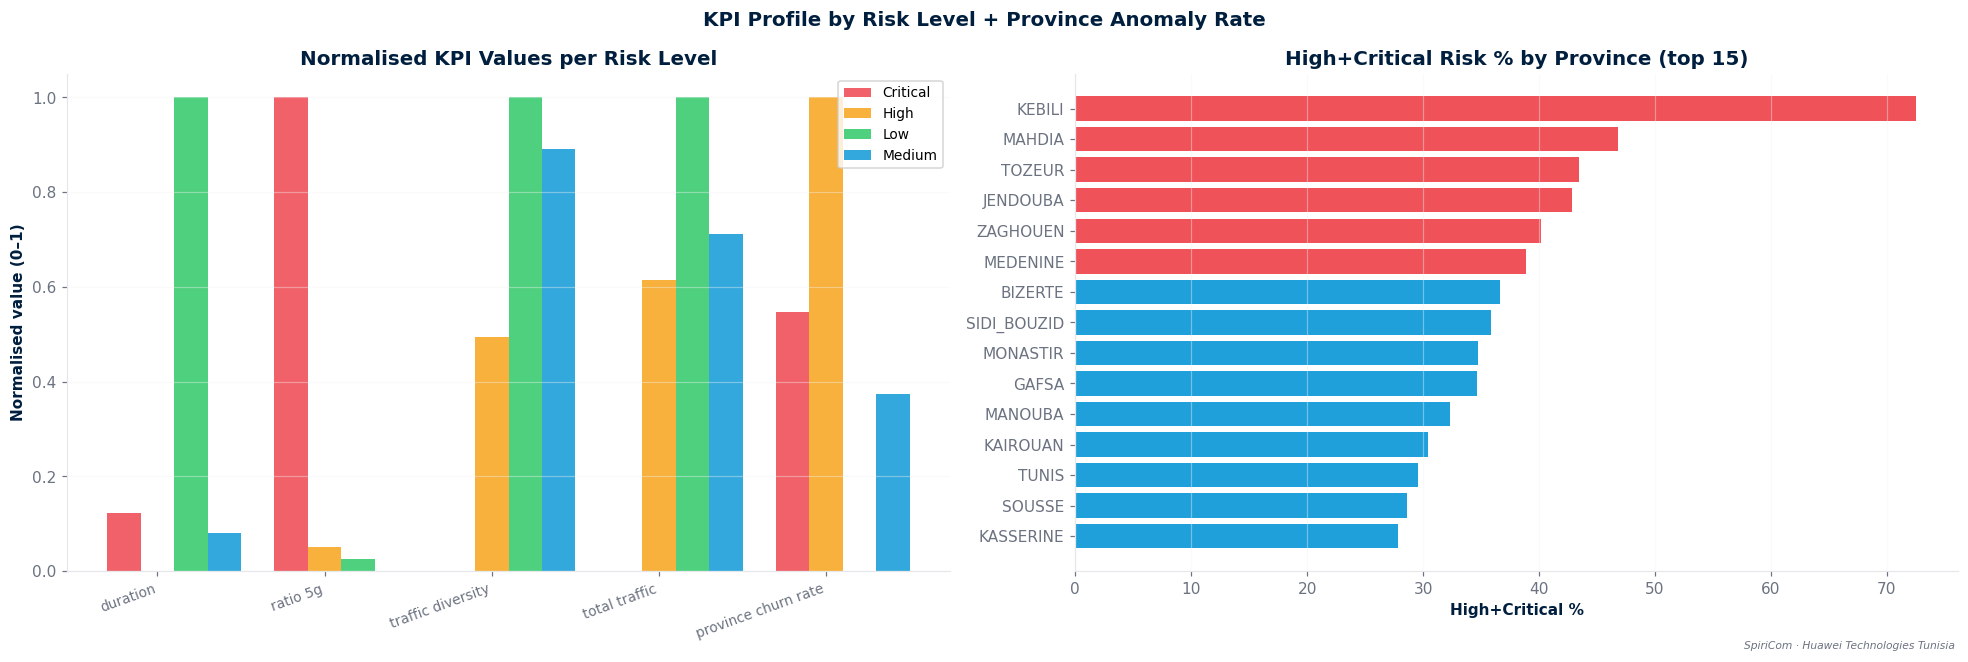

In [28]:
# ── 3.5  KPI profile by risk level + province hotspot ────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('KPI Profile by Risk Level + Province Anomaly Rate',
             fontsize=13, fontweight='bold', color=HW['navy'])

# Left: KPI means per risk level (top SHAP features only)
ax = axes[0]
top_feats = shap_df_all.head(5)['feature'].tolist()
top_feats = [f for f in top_feats if f in df.columns]

if top_feats and 'risk_level' in df.columns:
    kpi_by_risk = df.groupby('risk_level')[top_feats].mean()
    # Normalise each column 0-1 for radar-style comparison
    kpi_norm = (kpi_by_risk - kpi_by_risk.min()) / \
               (kpi_by_risk.max() - kpi_by_risk.min() + 1e-8)
    x_pos   = np.arange(len(top_feats))
    width   = 0.2
    for j, (idx, row) in enumerate(kpi_norm.iterrows()):
        ax.bar(x_pos + j*width, row.values,
               width, label=idx, color=risk_pal.get(idx, HW['muted']), alpha=0.8)
    ax.set_xticks(x_pos + width)
    ax.set_xticklabels([f.replace('avg_','').replace('_',' ') for f in top_feats],
                       rotation=20, ha='right', fontsize=9)
    ax.set_title('Normalised KPI Values per Risk Level')
    ax.set_ylabel('Normalised value (0–1)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4); ax.grid(axis='x', visible=False)

# Right: Province anomaly rate (top_anomaly_driver from NB07 if available)
ax = axes[1]
anom_path = MODEL_DIR / 'anomaly' / 'anomaly_results.parquet'
prov_col  = next((c for c in df.columns if 'province' in c.lower()), None)

if anom_path.exists() and prov_col:
    anom_df = pd.read_parquet(anom_path)
    anom_df.columns = anom_df.columns.str.lower().str.strip()

    # Load province map
    pmap = {}
    for lep in [MODEL_DIR/'le_province.pkl', MODEL_DIR/'churn_le_province.pkl']:
        if lep.exists():
            le_p = joblib.load(lep)
            pmap = {i: n for i, n in enumerate(le_p.classes_)}
            break
    if not pmap:
        _TN = ['Ariana','Béja','Ben Arous','Bizerte','Gabès','Gafsa',
               'Jendouba','Kairouan','Kasserine','Kébili','Kef','Mahdia',
               'Manouba','Médenine','Monastir','Nabeul','Sfax','Sidi Bouzid',
               'Siliana','Sousse','Tataouine','Tozeur','Tunis','Zaghouan']
        pmap = {i: n for i, n in enumerate(_TN)}

    prov_stats = df.groupby(prov_col).agg(
        subscribers=(prov_col,'count'),
        avg_ratio_5g=('ratio_5g','mean') if ratio_col else (prov_col,'count'),
        high_risk_pct=('risk_level', lambda x: (x.isin(['Critical','High'])).mean()*100)
        if 'risk_level' in df.columns else (prov_col,'count')
    ).reset_index()
    prov_stats['province'] = prov_stats[prov_col].apply(
        lambda x: pmap.get(int(x), f'P{x}')
    )
    prov_stats = prov_stats.sort_values('high_risk_pct', ascending=False)

    ax.barh(prov_stats['province'].head(15)[::-1],
            prov_stats['high_risk_pct'].head(15)[::-1],
            color=[HW['red'] if v > prov_stats['high_risk_pct'].quantile(0.75)
                   else HW['blue'] for v in prov_stats['high_risk_pct'].head(15)[::-1]],
            alpha=0.88)
    ax.set_title('High+Critical Risk % by Province (top 15)')
    ax.set_xlabel('High+Critical %')
    ax.grid(axis='x', alpha=0.4); ax.grid(axis='y', visible=False)
else:
    ax.text(0.5, 0.5, 'anomaly_results.parquet not available\nRun NB07 first',
            ha='center', va='center', transform=ax.transAxes,
            color=HW['muted'], fontsize=11)
    ax.set_title('Province Risk Distribution (no data)')

wm(fig); plt.tight_layout()
save_fig('fig08b_D_kpi_profile')
plt.show()

---
## §4 — Save Artifacts

In [29]:
# ── 4.1  Save model + results ─────────────────────────────────────────
joblib.dump(xgb_risk,     CLASS_DIR / 'xgb_risk_classifier.pkl')
joblib.dump(le_risk,      CLASS_DIR / 'le_risk.pkl')
joblib.dump(FEATURE_COLS, CLASS_DIR / 'rca_5g_feature_cols.pkl')

def clean_cr(rd):
    return {
        k: {'precision':round(float(v['precision']),4),
            'recall':   round(float(v['recall']),   4),
            'f1-score': round(float(v['f1-score']), 4),
            'support':  int(v['support'])}
        for k, v in rd.items() if isinstance(v, dict) and 'f1-score' in v
    }

rca_results = {
    'dataset':         'Dataset 2 — churn_features + churn_scores',
    'target_column':   TARGET_COL,
    'classes':         list(le_risk.classes_),
    'n_features':      len(FEATURE_COLS),
    'feature_cols':    FEATURE_COLS,
    'ratio_threshold': RATIO_THRESHOLD,
    'n_5g_subscribers': int(len(df_5g)) if ratio_col else 0,

    'xgb_report': {
        'accuracy':    round(float(acc),   4),
        'f1_macro':    round(float(f1_mac),4),
        'f1_weighted': round(float(f1_w),  4),
        'cv_f1_mean':  round(float(cv_scores.mean()),4),
        'cv_f1_std':   round(float(cv_scores.std()), 4),
        'classification_report': clean_cr(cr),
    },

    'feature_importance': sorted([
        {'feature': feat,
         'importance_xgb': round(float(xgb_risk.feature_importances_[i]),5),
         'shap_mean':      round(float(shap_df_all.set_index('feature').loc[feat,'shap_mean']
                                  if feat in shap_df_all['feature'].values else 0), 5),
         'shap_5g':        round(float(shap_df_5g.set_index('feature').loc[feat,'shap_5g']
                                  if feat in shap_df_5g['feature'].values else 0), 5),
         }
        for i, feat in enumerate(FEATURE_COLS)
    ], key=lambda x: x['shap_mean'], reverse=True),

    'shap_per_risk_level': per_class_shap,

    'top_5g_root_causes': shap_df_5g.head(8)[['feature','shap_5g']].to_dict(orient='records'),
    'top_5g_hi_root_causes': shap_df_5g_hi.head(8)[['feature','shap_hi']].to_dict(orient='records'),

    'confusion_matrix': cm_norm.tolist(),
}

out = CLASS_DIR / 'rca_5g_results.json'
with open(out, 'w', encoding='utf-8') as f:
    json.dump(rca_results, f, indent=2, ensure_ascii=False)
print(f'✅ rca_5g_results.json → {out}')

# ── 4.2  Summary ─────────────────────────────────────────────────────
print('\n' + '═'*60)
print('NB08b — 5G ROOT CAUSE ANALYSIS COMPLETE (Dataset 2)')
print('═'*60)
print(f'  Dataset        : Dataset 2 — churn_features + churn_scores')
print(f'  Target         : {TARGET_COL}  (4 classes)')
print(f'  Subscribers    : {len(df):,} total  |  {len(df_5g):,} 5G active')
print(f'  XGB F1-macro   : {f1_mac:.4f}  CV: {cv_scores.mean():.4f}±{cv_scores.std():.4f}')
print()
print('  Root cause answer — for 5G Critical+High risk subscribers:')
for _, row in shap_df_5g_hi.head(5).iterrows():
    bar = chr(9608) * int(row.shap_hi / shap_df_5g_hi.shap_hi.max() * 20)
    print(f'    {row.feature:<35s}: {row.shap_hi:.5f}  {bar}')
print()
print('  SHAP per risk level:')
for cls, feats in per_class_shap.items():
    top = feats[0]["feature"] if feats else "N/A"
    print(f'    {cls:<12s} → primary driver: {top}')
print()
print(f'  Artifacts → {CLASS_DIR}/')
print(f'    rca_5g_results.json  xgb_risk_classifier.pkl')
print(f'    le_risk.pkl  rca_5g_feature_cols.pkl')
print(f'  Dashboard: GET /api/analytics/root-cause/5g  ✅')

✅ rca_5g_results.json → models\classification\rca_5g_results.json

════════════════════════════════════════════════════════════
NB08b — 5G ROOT CAUSE ANALYSIS COMPLETE (Dataset 2)
════════════════════════════════════════════════════════════
  Dataset        : Dataset 2 — churn_features + churn_scores
  Target         : risk_level  (4 classes)
  Subscribers    : 4,896 total  |  1,157 5G active
  XGB F1-macro   : 0.9226  CV: 0.9080±0.0055

  Root cause answer — for 5G Critical+High risk subscribers:
    ratio_5g                           : 2.06353  ████████████████████
    duration                           : 1.11087  ██████████
    total_traffic                      : 0.94210  █████████
    traffic_diversity                  : 0.68069  ██████
    gaming_ratio                       : 0.32833  ███

  SHAP per risk level:
    Critical     → primary driver: ratio_5g
    High         → primary driver: duration
    Low          → primary driver: duration
    Medium       → primary driver: dur

---
## How this answers "find the true cause of a 5G problem"

```
Step 1: Filter subscribers with ratio_5g > 10% → 5G cohort
Step 2: XGBoost classifies each as Critical / High / Medium / Low risk
Step 3: SHAP decomposes which KPI feature contributed most to that prediction
Step 4: For Critical+High 5G subscribers specifically:
          → top SHAP feature = ROOT CAUSE of their 5G problem

Example interpretation:
  If avg_latency_ms is top SHAP driver for Critical 5G subscribers:
    → The root cause is BACKHAUL LATENCY
    → NOC action: check backhaul routing, peering points, transmission delays

  If ratio_5g is top SHAP driver:
    → The root cause is LOW 5G COVERAGE / DEVICE COMPATIBILITY
    → NOC action: deploy NR cells, run device upgrade campaign
```

**Note:** Dataset 1 (complaints) is handled independently in `08a_RootCauseAnalysis.ipynb`.
The two notebooks produce separate JSON files feeding different dashboard sections.

---
*SpiriCom · NOC Intelligence Platform · Huawei Technologies Tunisia · PFE 2026*